Veri seti hazır !!!
Toplam veri sayısı : 1006
Ortalama Boy : 9.9994
---------------
İlk 5 vida
   -----Vida Boyu----
0            9.962890
1           10.056302
2           10.089202
3            9.965920
4            9.876531
Olması gereken aralık 9.43 ile 10.57

 ---- AYKIRI DEĞERLER ----
      -----Vida Boyu----
1000                12.5
1001                 8.2
1002                10.9
1003                 7.5
1004                13.0
1005                 9.1


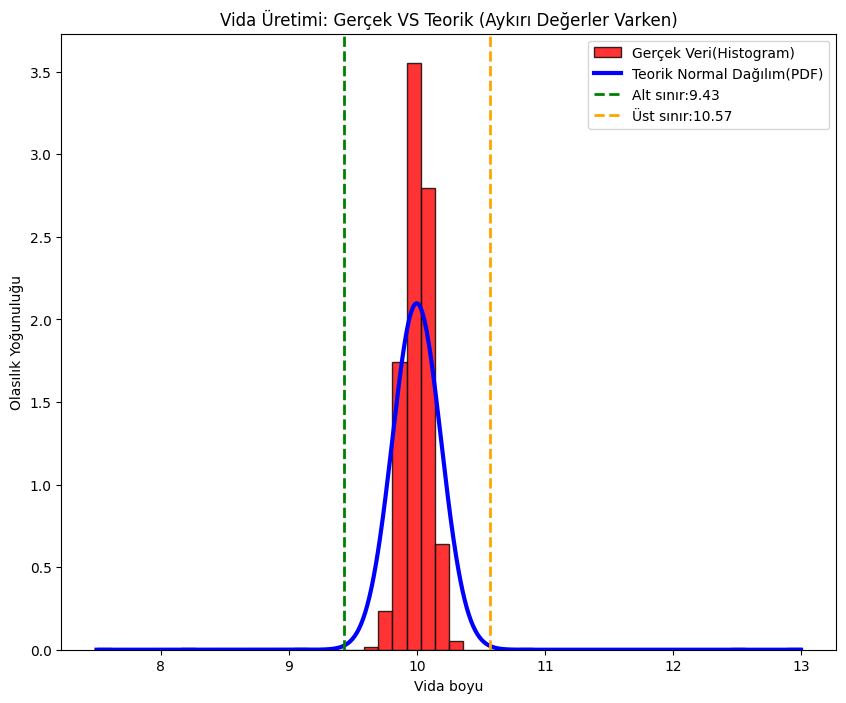

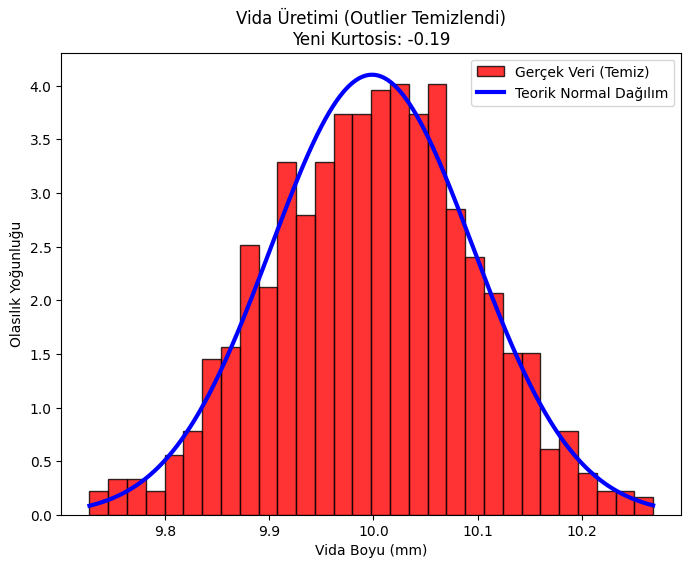

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1-)GERÇEK BİR ÜRETİMİ SİMÜLE ETMEK İÇİN VERİ ÜRETİYORUZ.
hedef_boy = 10     # İdeal vida boyutu
sapma = 0.1        # Standart sapma
hedef_sayi = 1000  # Üretmek istediğimiz toplam vida sayısı

# Vidaları normal dağılıma uygun  bir şekilde üretiyoruz.
saglam_vida = np.random.normal(hedef_boy, sapma, hedef_sayi)

# Üretimdeki bozuk vidaları yani aykırı değerleri(outlier) oluşturuyoruz.
bozuk_vida = np.array([12.5, 8.2, 10.9, 7.5, 13.0, 9.1])

# Sağlam ve bozuk vidaları tek bir üretim bandında birleştiriyoruz.
uretim_bandi = np.concatenate([saglam_vida, bozuk_vida])
df = pd.DataFrame(uretim_bandi, columns=["-----Vida Boyu----"])

print("Veri seti hazır !!!")
print(f"Toplam veri sayısı : {len(df)}")
print(f"Ortalama Boy : {df['-----Vida Boyu----'].mean():.4f}")
print("---" * 5)
print("İlk 5 vida")
print(df.head())

# 2-)İLK ANALİZ AŞAMASI VE HATA TESPİTİ
# Ham veri üzerinden ortalama ve standart sapma hesaplıyoruz.
ortalama = df['-----Vida Boyu----'].mean()
standart_sapma = df['-----Vida Boyu----'].std()

# Klasik 3-Sigma kuralına göre teorik sınırları belirliyoruz.
ust_sınır = ortalama + (3 * standart_sapma)
alt_sınır = ortalama - (3 * standart_sapma)

print(f"Olması gereken aralık {alt_sınır:.2f} ile {ust_sınır:.2f}")
outlier = df[(df['-----Vida Boyu----'] < alt_sınır) | (df['-----Vida Boyu----'] > ust_sınır)]
print("\n ---- AYKIRI DEĞERLER ----")
print(outlier)

# 3-)HAM VERİ ÜZERİNDEN İLK GÖRSELLEŞTİRME
# Aykırı değerler varken grafiğin nasıl bozulduğunu gözlemliyoruz.
plt.figure(figsize=(10,8))
# density=True: Y eksenini olasılık yoğunluğuna çevirerek histogram ve PDF'i ölçekliyoruz.
plt.hist(df['-----Vida Boyu----'], bins=50, density=True, color="Red", edgecolor="Black", alpha=0.8, label="Gerçek Veri(Histogram)")

x_ekseni = np.linspace(df['-----Vida Boyu----'].min(), df['-----Vida Boyu----'].max(), 1000)
pdf_egrisi = norm.pdf(x_ekseni, ortalama, standart_sapma)
plt.plot(x_ekseni, pdf_egrisi, "blue", linewidth=3, label="Teorik Normal Dağılım(PDF)")

plt.axvline(alt_sınır, color="green", linewidth=2, linestyle="--", label="Alt sınır:9.43")
plt.axvline(ust_sınır, color="orange", linewidth=2, linestyle="--", label="Üst sınır:10.57")
plt.title("Vida Üretimi: Gerçek VS Teorik (Aykırı Değerler Varken)")
plt.xlabel("Vida boyu")
plt.ylabel("Olasılık Yoğunuluğu")
plt.legend()
plt.show()

# 4-)IQR YÖNTEMİ İLE VERİ TEMİZLEME
# Standart sapmayı şişiren aykırı değerleri Çeyrekler Açıklığı (IQR) ile ayıklıyoruz.

# Çeyrek değerlerini (Q1 ve Q3) hesaplıyoruz
Q1 = df['-----Vida Boyu----'].quantile(0.25)
Q3 = df['-----Vida Boyu----'].quantile(0.75)
IQR = Q3 - Q1 # Merkezin genişliği

# 1.5 * IQR kuralı ile "güvenli bölge" sınırlarını belirliyoruz
alt_sinir_outlier = Q1 - 1.5 * IQR
ust_sinir_outlier = Q3 + 1.5 * IQR

# Sınırların dışında kalan gürültülü verileri temizliyoruz.
df_temiz = df[(df['-----Vida Boyu----'] >= alt_sinir_outlier) & (df['-----Vida Boyu----'] <= ust_sinir_outlier)]

# 5-)TEMİZLENEN VERİ ÜZERİNDEN 2.GÖRSELLEŞTİRME
# Temizlenmiş veriyle teorik eğrinin nasıl mükemmel uyum sağladığını görüyoruz.
plt.figure(figsize=(8,6))

# Histogram (Temiz veri ile)
plt.hist(df_temiz['-----Vida Boyu----'], bins=30, density=True, color="Red", edgecolor="Black", alpha=0.8, label="Gerçek Veri (Temiz)")

# Temizlenmiş verinin istatistikleri
mu_temiz = df_temiz['-----Vida Boyu----'].mean()
std_temiz = df_temiz['-----Vida Boyu----'].std()

# Yeni PDF eğrisi (Temizlenmiş sapma ile tepesi yükselen eğri)
x_ekseni_temiz = np.linspace(df_temiz['-----Vida Boyu----'].min(), df_temiz['-----Vida Boyu----'].max(), 1000)
pdf_egrisi_temiz = norm.pdf(x_ekseni_temiz, mu_temiz, std_temiz)
plt.plot(x_ekseni_temiz, pdf_egrisi_temiz, "blue", linewidth=3, label="Teorik Normal Dağılım")

plt.title(f"Vida Üretimi (Outlier Temizlendi)\nYeni Kurtosis: {df_temiz['-----Vida Boyu----'].kurt():.2f}")
plt.xlabel("Vida Boyu (mm)")
plt.ylabel("Olasılık Yoğunluğu")
plt.legend()
plt.show()